In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
df = pd.read_csv("../data/online_retail.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [7]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

Data types:
Invoice            str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
Price          float64
Customer ID    float64
Country            str
dtype: object


In [8]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Duplicate rows: 34335


In [ ]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

df[["Quantity", "UnitPrice", "Revenue"]].head()

In [10]:
print(df.columns.tolist())

['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [11]:
df["Revenue"] = df["Quantity"] * df["Price"]

df[["Quantity", "Price", "Revenue"]].head()

,Quantity,Price,Revenue
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


In [12]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print("Start Date:", df["InvoiceDate"].min())
print("End Date:", df["InvoiceDate"].max())

Start Date: 2009-12-01 07:45:00
End Date: 2011-12-09 12:50:00


In [13]:
print("Total Revenue:", df["Revenue"].sum())
print("Average Revenue per transaction:", df["Revenue"].mean())

Total Revenue: 19287250.568
Average Revenue per transaction: 18.06986564933842


In [14]:
df["Date"] = df["InvoiceDate"].dt.date

df[["InvoiceDate", "Date", "Revenue"]].head()

daily_sales = df.groupby("Date")["Revenue"].sum().reset_index()

daily_sales.head()

,Date,Revenue
0,2009-12-01,53173.03
1,2009-12-02,62763.59
2,2009-12-03,68093.05
3,2009-12-04,40346.40
4,2009-12-05,9803.05


In [15]:
daily_sales["Date"] = pd.to_datetime(daily_sales["Date"])

print("Daily sales shape:", daily_sales.shape)
print(daily_sales.dtypes)

Daily sales shape: (604, 2)
Date       datetime64[s]
Revenue          float64
dtype: object


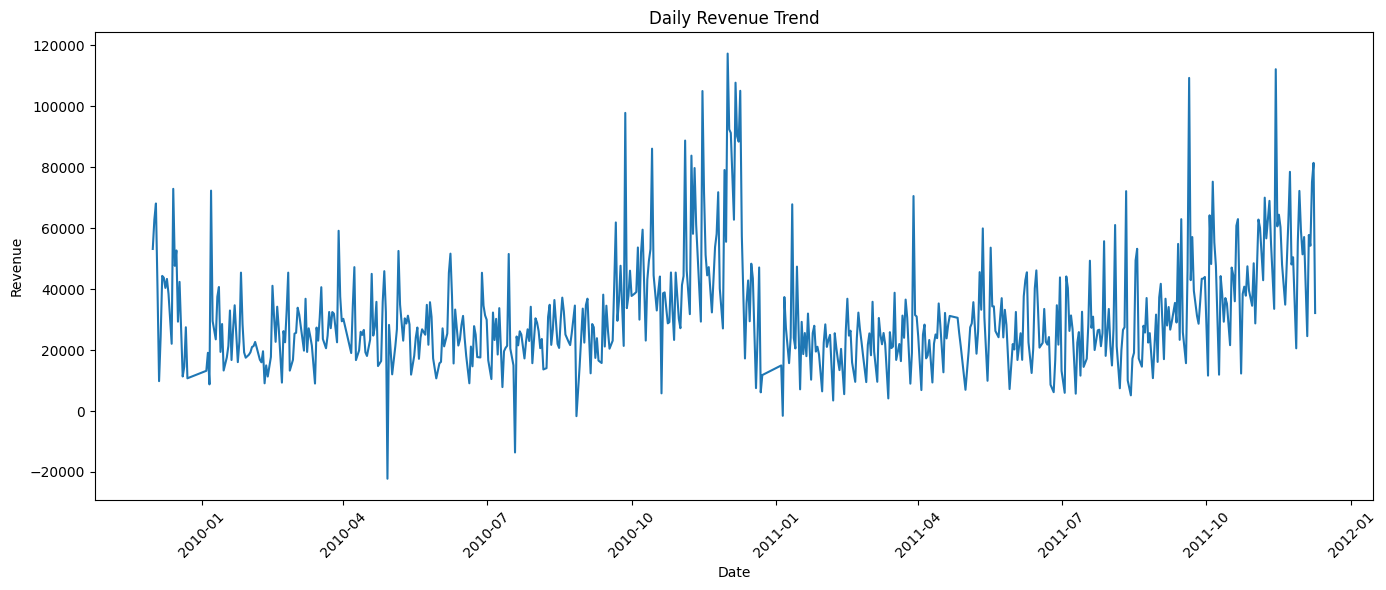

In [16]:
plt.figure(figsize=(14, 6))

plt.plot(daily_sales["Date"], daily_sales["Revenue"])

plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

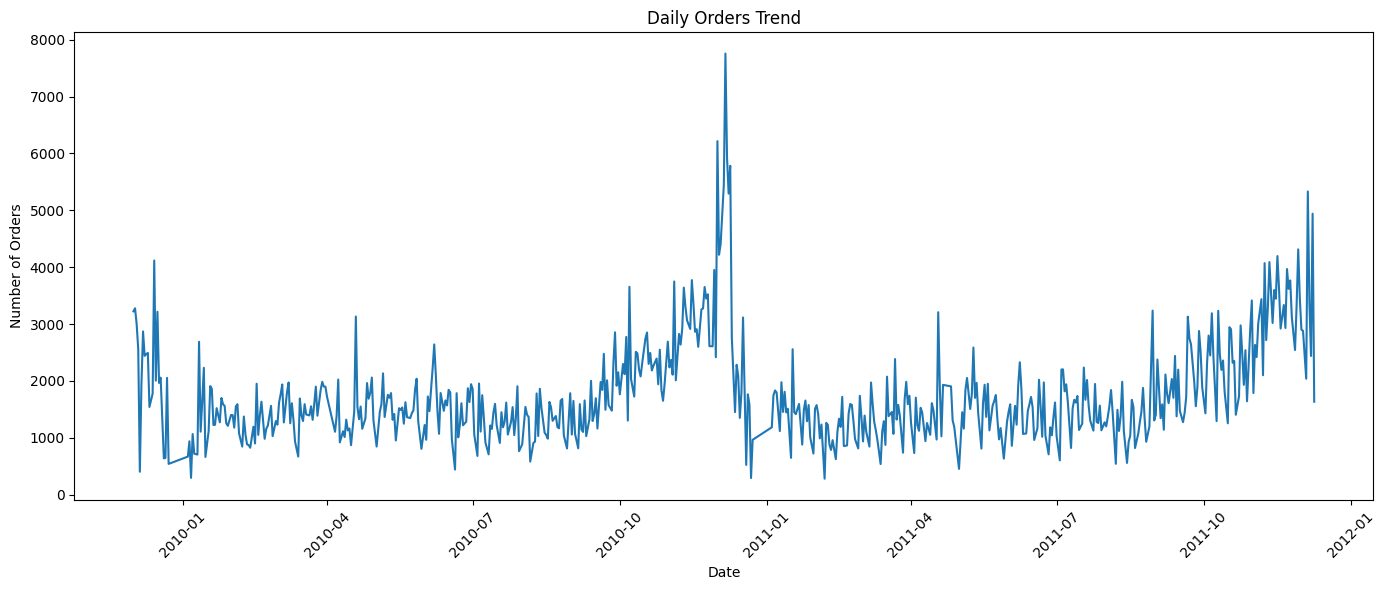

In [19]:
# Daily Orders Trend

daily_orders = (
    df.groupby("Date")
      .size()
      .reset_index(name="Orders")
)

plt.figure(figsize=(14, 6))

plt.plot(daily_orders["Date"], daily_orders["Orders"])

plt.title("Daily Orders Trend")
plt.xlabel("Date")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [22]:
# Create Month column from Date

df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.to_period("M").astype(str)

print(df[["Date", "Month"]].head())

        Date    Month
0 2009-12-01  2009-12
1 2009-12-01  2009-12
2 2009-12-01  2009-12
3 2009-12-01  2009-12
4 2009-12-01  2009-12


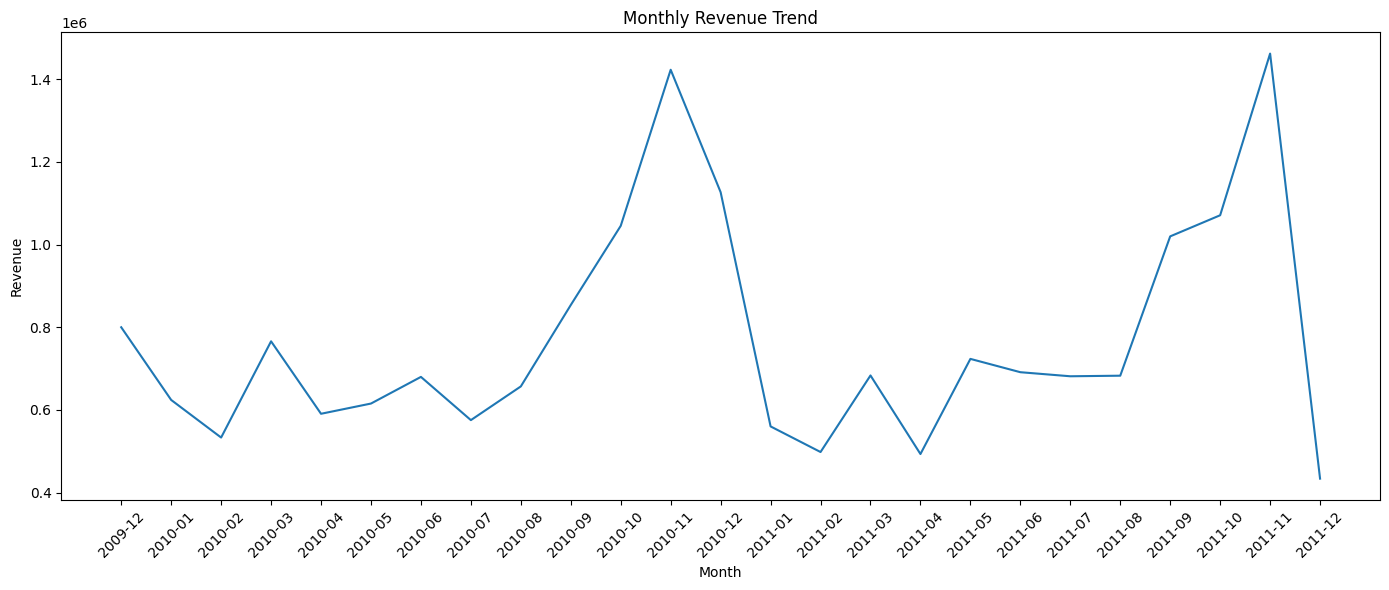

In [23]:
# Monthly Revenue Trend

monthly_revenue = (
    df.groupby("Month")["Revenue"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(14, 6))

plt.plot(monthly_revenue["Month"], monthly_revenue["Revenue"])

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

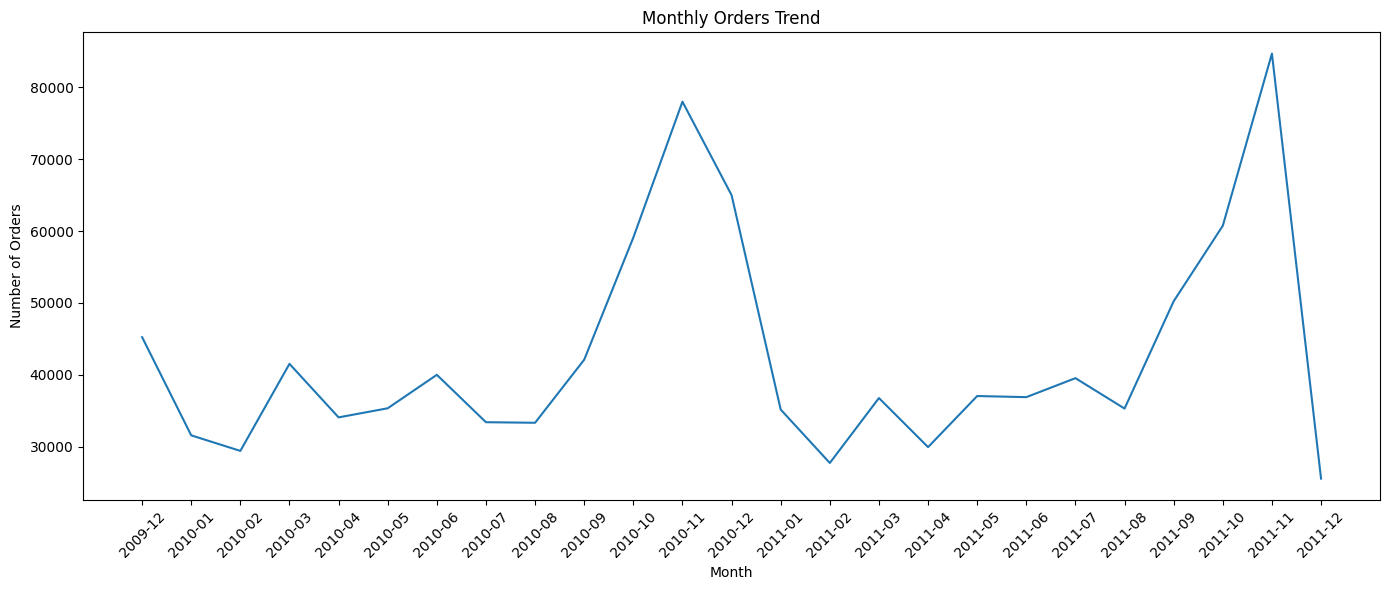

In [24]:
# Monthly Orders Trend

monthly_orders = (
    df.groupby("Month")
      .size()
      .reset_index(name="Orders")
)

plt.figure(figsize=(14, 6))

plt.plot(monthly_orders["Month"], monthly_orders["Orders"])

plt.title("Monthly Orders Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [25]:
# Top 10 Customers by Revenue

top_customers = (
    df.groupby("Customer ID")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

print(top_customers)

   Customer ID    Revenue
0      18102.0  598215.22
1      14646.0  523342.07
2      14156.0  296564.69
3      14911.0  270248.53
4      17450.0  233579.39
5      13694.0  190825.52
6      17511.0  171885.98
7      12415.0  143269.29
8      16684.0  141502.25
9      15061.0  136391.48


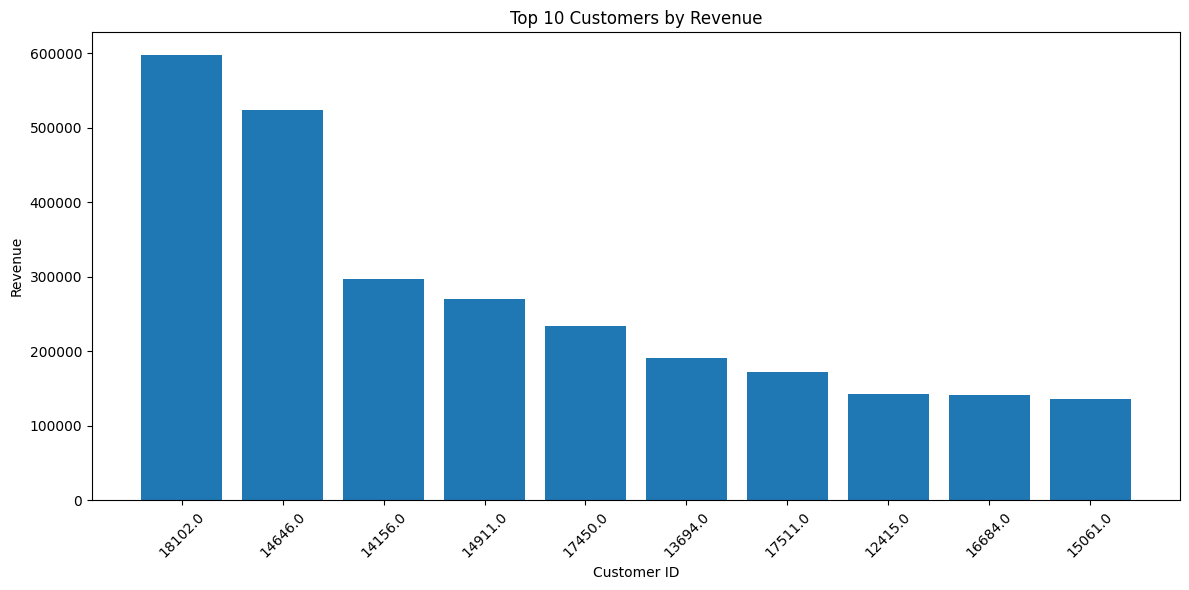

In [26]:
plt.figure(figsize=(12, 6))

plt.bar(
    top_customers["Customer ID"].astype(str),
    top_customers["Revenue"]
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [27]:
# Top 10 Products by Revenue

top_products = (
    df.groupby("Description")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

print(top_products)

                           Description    Revenue
0             REGENCY CAKESTAND 3 TIER  327813.65
1                       DOTCOM POSTAGE  322647.47
2   WHITE HANGING HEART T-LIGHT HOLDER  257533.90
3              JUMBO BAG RED RETROSPOT  148800.64
4                        PARTY BUNTING  147948.50
5        ASSORTED COLOUR BIRD ORNAMENT  131413.85
6      PAPER CHAIN KIT 50'S CHRISTMAS   121662.14
7                              POSTAGE  112341.00
8                        CHILLI LIGHTS   84854.16
9  ROTATING SILVER ANGELS T-LIGHT HLDR   73814.72


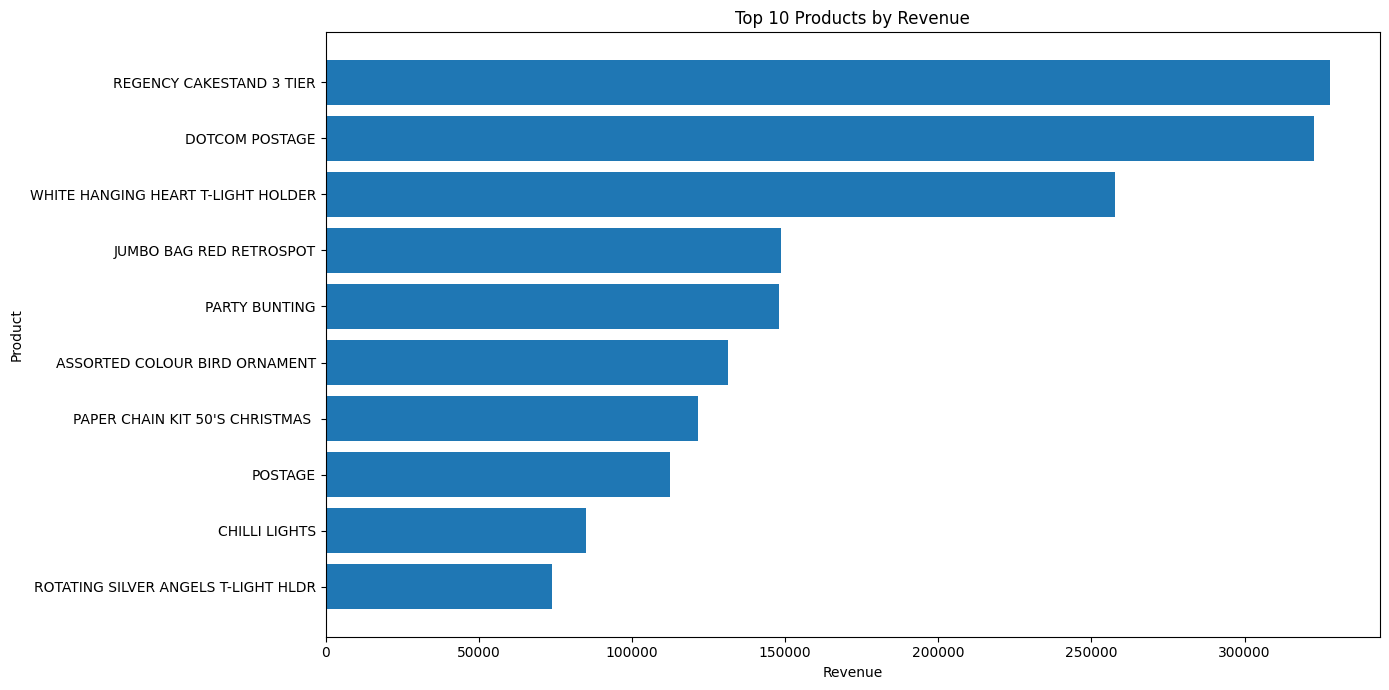

In [28]:
plt.figure(figsize=(14, 7))

plt.barh(
    top_products["Description"].astype(str),
    top_products["Revenue"]
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [29]:
print(df.columns.tolist())

['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Revenue', 'Date', 'Month']


In [30]:
df["Date"] = pd.to_datetime(df["Date"])

print(df["Date"].max())

2011-12-09 00:00:00


In [31]:
# Reference date = one day after the last transaction
reference_date = df["Date"].max() + pd.Timedelta(days=1)

rfm = (
    df.groupby("Customer ID")
      .agg({
          "Date": lambda x: (reference_date - x.max()).days,
          "Invoice": "nunique",
          "Revenue": "sum"
      })
      .reset_index()
)

rfm.columns = ["Customer ID", "Recency", "Frequency", "Monetary"]

print(rfm.head())
print(rfm.shape)

   Customer ID  Recency  Frequency  Monetary
0      12346.0      326         17    -64.68
1      12347.0        3          8   5633.32
2      12348.0       76          5   2019.40
3      12349.0       19          5   4404.54
4      12350.0      311          1    334.40
(5942, 4)


In [32]:
rfm["R Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5, 4, 3, 2, 1],
    duplicates="drop"
).astype(int)

rfm["F Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["M Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["RFM Score"] = (
    rfm["R Score"].astype(str) +
    rfm["F Score"].astype(str) +
    rfm["M Score"].astype(str)
)

print(rfm.head())

   Customer ID  Recency  Frequency  Monetary  R Score  F Score  M Score  \
0      12346.0      326         17    -64.68        2        5        1   
1      12347.0        3          8   5633.32        5        4        5   
2      12348.0       76          5   2019.40        3        3        4   
3      12349.0       19          5   4404.54        5        3        5   
4      12350.0      311          1    334.40        2        1        2   

  RFM Score  
0       251  
1       545  
2       334  
3       535  
4       212  


In [33]:
def customer_segment(row):
    r = row["R Score"]
    f = row["F Score"]
    m = row["M Score"]

    if r >= 4 and f >= 4 and m >= 4:
        return "VIP Customer"

    elif r >= 3 and f >= 4:
        return "Loyal Customer"

    elif r >= 4 and f <= 2:
        return "Recent Customer"

    elif r <= 2 and f >= 3:
        return "At Risk"

    else:
        return "Regular Customer"


rfm["Customer Segment"] = rfm.apply(customer_segment, axis=1)

print(rfm["Customer Segment"].value_counts())


Customer Segment
Regular Customer    2637
VIP Customer        1317
At Risk              837
Loyal Customer       689
Recent Customer      462
Name: count, dtype: int64


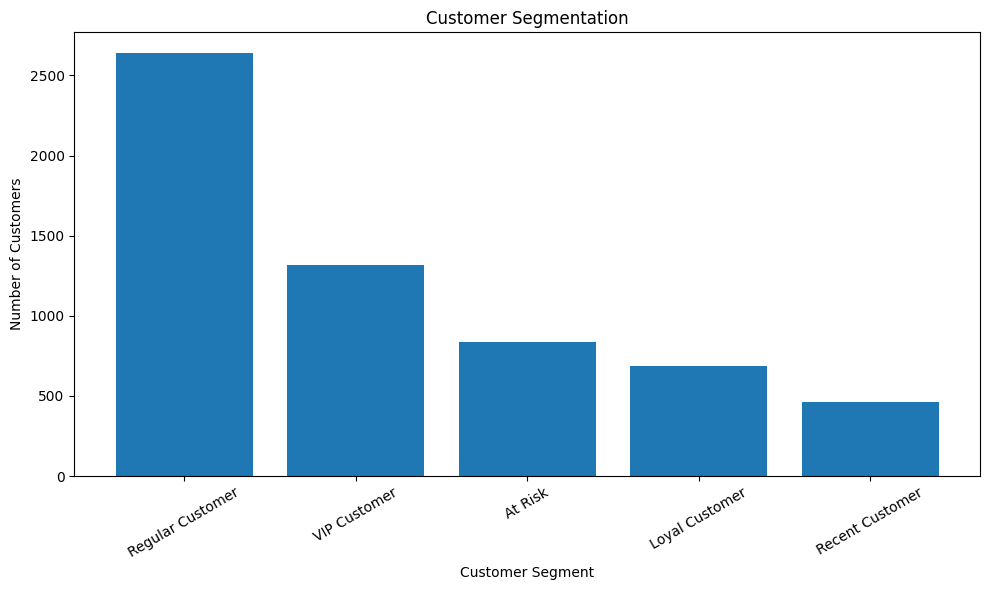

In [34]:
segment_counts = rfm["Customer Segment"].value_counts()

plt.figure(figsize=(10, 6))

plt.bar(
    segment_counts.index,
    segment_counts.values
)

plt.title("Customer Segmentation")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [35]:
rfm.to_csv("customer_rfm_analysis.csv", index=False)

print("RFM analysis saved successfully!")
print(rfm.shape)

RFM analysis saved successfully!
(5942, 9)


In [36]:
print(rfm.head())

   Customer ID  Recency  Frequency  Monetary  R Score  F Score  M Score  \
0      12346.0      326         17    -64.68        2        5        1   
1      12347.0        3          8   5633.32        5        4        5   
2      12348.0       76          5   2019.40        3        3        4   
3      12349.0       19          5   4404.54        5        3        5   
4      12350.0      311          1    334.40        2        1        2   

  RFM Score  Customer Segment  
0       251           At Risk  
1       545      VIP Customer  
2       334  Regular Customer  
3       535  Regular Customer  
4       212  Regular Customer  


In [37]:
segment_summary = (
    rfm.groupby("Customer Segment")
       .agg(
           Customers=("Customer ID", "count"),
           Total_Revenue=("Monetary", "sum"),
           Average_Revenue=("Monetary", "mean")
       )
       .reset_index()
)

print(segment_summary)

   Customer Segment  Customers  Total_Revenue  Average_Revenue
0           At Risk        837   1.357081e+06      1621.363252
1    Loyal Customer        689   1.813237e+06      2631.693811
2   Recent Customer        462   2.396638e+05       518.752900
3  Regular Customer       2637   1.493256e+06       566.270920
4      VIP Customer       1317   1.174505e+07      8918.036488


In [38]:
segment_summary.to_csv(
    "customer_segment_summary.csv",
    index=False
)

print("Customer segment summary saved successfully!")

Customer segment summary saved successfully!


In [39]:
# Revenue by Customer Segment

segment_revenue = (
    rfm.groupby("Customer Segment")["Monetary"]
       .sum()
       .sort_values(ascending=False)
       .reset_index()
)

print(segment_revenue)

   Customer Segment      Monetary
0      VIP Customer  1.174505e+07
1    Loyal Customer  1.813237e+06
2  Regular Customer  1.493256e+06
3           At Risk  1.357081e+06
4   Recent Customer  2.396638e+05


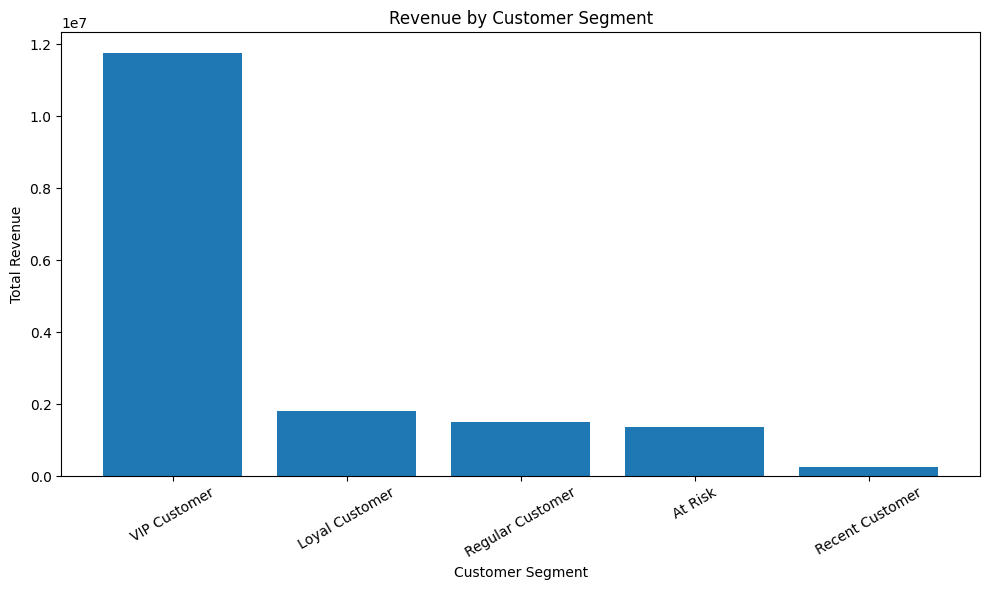

In [40]:
plt.figure(figsize=(10, 6))

plt.bar(
    segment_revenue["Customer Segment"],
    segment_revenue["Monetary"]
)

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [41]:
# Business Recommendations

recommendations = {
    "VIP Customer":
        "Provide premium offers, loyalty rewards, and personalized recommendations.",

    "Loyal Customer":
        "Use loyalty programs, cross-selling, and repeat-purchase offers.",

    "Recent Customer":
        "Send welcome offers and personalized product recommendations to encourage a second purchase.",

    "At Risk":
        "Launch re-engagement campaigns, targeted discounts, and reminders to bring customers back.",

    "Regular Customer":
        "Use personalized promotions and cross-selling to increase purchase frequency."
}

rfm["Recommendation"] = rfm["Customer Segment"].map(recommendations)

print(
    rfm[
        ["Customer ID", "Customer Segment", "Monetary", "Recommendation"]
    ].head(10)
)

   Customer ID  Customer Segment  Monetary  \
0      12346.0           At Risk    -64.68   
1      12347.0      VIP Customer   5633.32   
2      12348.0  Regular Customer   2019.40   
3      12349.0  Regular Customer   4404.54   
4      12350.0  Regular Customer    334.40   
5      12351.0  Regular Customer    300.93   
6      12352.0      VIP Customer   1889.21   
7      12353.0  Regular Customer    406.76   
8      12354.0  Regular Customer   1079.40   
9      12355.0  Regular Customer    947.61   

                                      Recommendation  
0  Launch re-engagement campaigns, targeted disco...  
1  Provide premium offers, loyalty rewards, and p...  
2  Use personalized promotions and cross-selling ...  
3  Use personalized promotions and cross-selling ...  
4  Use personalized promotions and cross-selling ...  
5  Use personalized promotions and cross-selling ...  
6  Provide premium offers, loyalty rewards, and p...  
7  Use personalized promotions and cross-selling ... 

In [42]:
rfm.to_csv(
    "customer_decision_support.csv",
    index=False
)

print("Decision support file saved successfully!")

Decision support file saved successfully!
